In [128]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Análisis Exploratorio de Datos

In [129]:
# Cargamos los datos
data = pd.read_csv('competition_data.csv')
submission = pd.read_csv('submission.csv')
submission_aux = pd.read_csv('submission.csv')

In [130]:
print(data.shape)
print(submission.shape)

(100144, 13)
(25037, 12)


In [131]:
data

,Unnamed: 0,ts,username,platform,conn_country,user_agent_decrypted,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,reason_start,shuffle,TARGET
0,110163,2018-03-11T05:05:45Z,11145402699,"iOS 11.0 (iPhone8,1)",AR,NaN,Crazy For U,Big Time Rush,24/seven,spotify:track:3jFfr89lnSmb4QBtfG8JBP,clickrow,False,False
1,66026,2023-06-05T10:42:33Z,11145402699,ios,AR,unknown,Nada Personal - Remasterizado 2007,Soda Stereo,Me Verás Volver (Hits & Más),spotify:track:09TTeexnlKewZdjOak2sV2,trackdone,True,False
2,116790,2018-07-01T02:04:51Z,11145402699,"iOS 11.0 (iPhone8,1)",AR,unknown,Good Times,CHIC,Risqué,spotify:track:0G3fbPbE1vGeABDEZF0jeG,trackdone,True,True
3,18431,2019-09-08T04:58:07Z,11145402699,"iOS 12.4 (iPhone8,1)",AR,unknown,Verano del 92,Los Piojos,3er Arco,spotify:track:1NXvuBAq48QrxRFQZVmORQ,trackdone,False,True
4,82941,2017-07-13T18:13:52Z,11145402699,"iOS 11.0 (iPhone8,1)",AR,NaN,Simpatico,Ekko Park,Simpatico,spotify:track:2gYJY0sIx1ErgTIha2nPRg,trackdone,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
100139,78756,2017-04-06T20:31:14Z,11145402699,"iOS 10.2.1 (iPad6,8,1)",AR,NaN,Losing My Religion,R.E.M.,In Time: The Best Of R.E.M. 1988-2003,spotify:track:12axV6NUqaYH3yFUWwArzr,trackdone,True,False
100140,12585,2021-11-03T21:06:07Z,11145402699,"iOS 15.1 (iPhone12,3)",AR,unknown,Cerca De La Revolucion,Charly García,Piano Bar,spotify:track:66grIvFLGrI4tNhggO2DAd,trackdone,True,False
100141,93960,2022-01-14T01:13:42Z,11145402699,"iOS 15.2 (iPhone12,3)",AR,unknown,A Los Jóvenes De Ayer - Remastered 2012,Serú Girán,Bicicleta,spotify:track:6YAl320SfxLO4rVIZTFKqG,trackdone,True,False
100142,74339,2024-05-01T17:51:16Z,11145402699,ios,AR,NaN,heat not hot,Serengeti,heat not hot,spotify:track:0rKLO1hXpmoIthQgJKoczN,trackdone,True,False


In [132]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100144 entries, 0 to 100143
Data columns (total 13 columns):
 #   Column                             Non-Null Count   Dtype 
---  ------                             --------------   ----- 
 0   Unnamed: 0                         100144 non-null  int64 
 1   ts                                 100144 non-null  object
 2   username                           100144 non-null  int64 
 3   platform                           100144 non-null  object
 4   conn_country                       100144 non-null  object
 5   user_agent_decrypted               83747 non-null   object
 6   master_metadata_track_name         99171 non-null   object
 7   master_metadata_album_artist_name  99171 non-null   object
 8   master_metadata_album_album_name   99171 non-null   object
 9   spotify_track_uri                  99171 non-null   object
 10  reason_start                       100140 non-null  object
 11  shuffle                            100144 non-null  

In [133]:
data_cat = data.select_dtypes(include='object').columns.tolist()
data_num = data.select_dtypes(include='number').columns.tolist()
data_bool = data.select_dtypes(include='bool').columns.tolist()

print(f"Variables categóricas: {data_cat}")
print(f"Variables numéricas: {data_num}")
print(f"Variables booleanas: {data_bool}")

Variables categóricas: ['ts', 'platform', 'conn_country', 'user_agent_decrypted', 'master_metadata_track_name', 'master_metadata_album_artist_name', 'master_metadata_album_album_name', 'spotify_track_uri', 'reason_start']
Variables numéricas: ['Unnamed: 0', 'username']
Variables booleanas: ['shuffle', 'TARGET']


In [134]:
# Resumen estadístico de data (mean, desvío estándar, varianza, etc para cada columna)
data.describe(include='all')

,Unnamed: 0,ts,username,platform,conn_country,user_agent_decrypted,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,reason_start,shuffle,TARGET
count,100144.000000,100144,1.001440e+05,100144,100144,83747,99171,99171,99171,99171,100140,100144,100144
unique,NaN,85548,NaN,75,7,20,8631,3179,6299,10231,9,2,2
top,NaN,2017-06-09T19:45:29Z,NaN,"iOS 11.0 (iPhone8,1)",AR,unknown,Rain,Charly García,Little Creatures,spotify:track:5hVghJ4KaYES3BFUATCYn0,fwdbtn,True,True
freq,NaN,84,NaN,18346,98007,83088,344,2066,794,263,39765,76052,52752
mean,62656.589970,NaN,1.114540e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,36145.052976,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,1.114540e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,31372.500000,NaN,1.114540e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,62674.500000,NaN,1.114540e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,93931.250000,NaN,1.114540e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [135]:
# Chequeamos missings
data.isnull().sum()  

Unnamed: 0                               0
ts                                       0
username                                 0
platform                                 0
conn_country                             0
user_agent_decrypted                 16397
master_metadata_track_name             973
master_metadata_album_artist_name      973
master_metadata_album_album_name       973
spotify_track_uri                      973
reason_start                             4
shuffle                                  0
TARGET                                   0
dtype: int64

In [136]:
# Chequeamos si hay filas duplicadas
data.duplicated().sum()

np.int64(0)

In [137]:
# Distribución de variables
for col in data.columns:
    if col != "Unnamed: 0":
        print(f"Atributo: {col}")
        print(data[col].value_counts())
        print("\n")

Atributo: ts
ts
2017-06-09T19:45:29Z    84
2020-02-13T01:40:31Z    82
2019-01-31T03:03:46Z    77
2019-01-28T22:40:57Z    71
2022-07-31T00:47:02Z    70
                        ..
2018-08-07T11:32:52Z     1
2019-11-10T17:09:17Z     1
2017-09-06T01:05:02Z     1
2019-08-25T21:00:28Z     1
2019-09-08T04:58:07Z     1
Name: count, Length: 85548, dtype: int64


Atributo: username
username
11145402699    100144
Name: count, dtype: int64


Atributo: platform
platform
iOS 11.0 (iPhone8,1)                                                      18346
iOS 12.0 (iPhone8,1)                                                      11574
ios                                                                       10622
OS X 10.15.5 [x86 8]                                                       5202
iOS 13.2.2 (iPhone8,1)                                                     4099
                                                                          ...  
Partner ios_sdk Apple;iPhone8.1;965a7538445247fbb2c635e5cf

In [138]:
submission

,Unnamed: 0,ts,username,platform,conn_country,user_agent_decrypted,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,reason_start,shuffle
0,32933,2020-04-22T03:12:40Z,11145402699,OS X 10.15.4 [x86 8],AR,unknown,(Your Love Keeps Lifting Me) Higher & Higher,Jackie Wilson,The Ultimate Jackie Wilson,spotify:track:4TBBPZks71c60whhq0PgdP,trackdone,True
1,32713,2020-04-17T19:40:02Z,11145402699,OS X 10.15.4 [x86 8],AR,unknown,Soul Sacrifice,Santana,Santana (Legacy Edition),spotify:track:4e0GkgtMPZFt41Ua8PlHQL,fwdbtn,True
2,90799,2017-11-22T13:46:08Z,11145402699,"iOS 11.0 (iPhone8,1)",AR,NaN,Voyage voyage,Desireless,François,spotify:track:2d8D7uk3tbAThjRkdfrx9c,fwdbtn,True
3,30990,2020-03-22T18:15:46Z,11145402699,OS X 10.15.1 [x86 8],AR,unknown,Penny Lane - Remastered 2009,The Beatles,Magical Mystery Tour,spotify:track:1h04XMpzGzmAudoI6VHBgA,fwdbtn,True
4,110120,2018-03-10T17:54:56Z,11145402699,"iOS 11.0 (iPhone8,1)",AR,NaN,"Breaking Free - From ""High School Musical""",High School Musical Cast,The Very Best West End Musicals - This Century,spotify:track:5QQOO2zF8vyyfICow4r5Cq,clickrow,True
...,...,...,...,...,...,...,...,...,...,...,...,...
25032,14029,2021-12-04T14:59:21Z,11145402699,OS X 12.0.1 [arm 2],AR,unknown,Lucky Nights,Lucas Estrada,Lucky Nights,spotify:track:2nTePC0sPbtVnnjYgPz7ff,fwdbtn,True
25033,110726,2018-03-30T02:58:16Z,11145402699,OS X 10.13.3 [x86 8],AR,NaN,Put On Your Sunday Clothes,Jerry Herman,"Hello, Dolly!",spotify:track:1M2zeYn9S4zorVjz05oZw1,trackdone,False
25034,86934,2017-09-10T15:48:19Z,11145402699,"iOS 11.0 (iPhone8,1)",AR,NaN,Comfortably Numb,Pink Floyd,The Wall,spotify:track:5HNCy40Ni5BZJFw1TKzRsC,trackdone,True
25035,84199,2017-07-30T21:49:52Z,11145402699,"iOS 11.0 (iPhone8,1)",AR,NaN,Tragedy,Bee Gees,Spirits Having Flown,spotify:track:04waBn6uK4Af8udH2KqQri,clickrow,True


In [139]:
submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25037 entries, 0 to 25036
Data columns (total 12 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Unnamed: 0                         25037 non-null  int64 
 1   ts                                 25037 non-null  object
 2   username                           25037 non-null  int64 
 3   platform                           25037 non-null  object
 4   conn_country                       25037 non-null  object
 5   user_agent_decrypted               20984 non-null  object
 6   master_metadata_track_name         24782 non-null  object
 7   master_metadata_album_artist_name  24782 non-null  object
 8   master_metadata_album_album_name   24782 non-null  object
 9   spotify_track_uri                  24782 non-null  object
 10  reason_start                       25036 non-null  object
 11  shuffle                            25037 non-null  bool  
dtypes: b

In [140]:
submission.describe(include='all')

,Unnamed: 0,ts,username,platform,conn_country,user_agent_decrypted,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,reason_start,shuffle
count,25037.000000,25037,2.503700e+04,25037,25037,20984,24782,24782,24782,24782,25036,25037
unique,NaN,23115,NaN,66,7,15,4166,1757,3238,4912,9,2
top,NaN,2020-02-13T01:40:31Z,NaN,"iOS 11.0 (iPhone8,1)",AR,unknown,Rain,Charly García,Artaud,spotify:track:5hVghJ4KaYES3BFUATCYn0,fwdbtn,True
freq,NaN,19,NaN,4387,24494,20815,82,533,188,66,9996,18948
mean,62323.650757,NaN,1.114540e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,36103.195505,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,4.000000,NaN,1.114540e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,31001.000000,NaN,1.114540e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,62241.000000,NaN,1.114540e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,93653.000000,NaN,1.114540e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [141]:
submission.isnull().sum() 

Unnamed: 0                              0
ts                                      0
username                                0
platform                                0
conn_country                            0
user_agent_decrypted                 4053
master_metadata_track_name            255
master_metadata_album_artist_name     255
master_metadata_album_album_name      255
spotify_track_uri                     255
reason_start                            1
shuffle                                 0
dtype: int64

In [142]:
submission.duplicated().sum()

np.int64(0)

In [143]:
for col in submission.columns:
    if col != "Unnamed: 0":
        print(f"Atributo: {col}")
        print(data[col].value_counts())
        print("\n")

Atributo: ts
ts
2017-06-09T19:45:29Z    84
2020-02-13T01:40:31Z    82
2019-01-31T03:03:46Z    77
2019-01-28T22:40:57Z    71
2022-07-31T00:47:02Z    70
                        ..
2018-08-07T11:32:52Z     1
2019-11-10T17:09:17Z     1
2017-09-06T01:05:02Z     1
2019-08-25T21:00:28Z     1
2019-09-08T04:58:07Z     1
Name: count, Length: 85548, dtype: int64


Atributo: username
username
11145402699    100144
Name: count, dtype: int64


Atributo: platform
platform
iOS 11.0 (iPhone8,1)                                                      18346
iOS 12.0 (iPhone8,1)                                                      11574
ios                                                                       10622
OS X 10.15.5 [x86 8]                                                       5202
iOS 13.2.2 (iPhone8,1)                                                     4099
                                                                          ...  
Partner ios_sdk Apple;iPhone8.1;965a7538445247fbb2c635e5cf

Ahora, empezamos a modificar ambos dataframes

In [144]:
# Eliminamos columnas que no vamos a usar
data = data.drop(columns=['username', 'conn_country', 'user_agent_decrypted'])
submission = submission.drop(columns=['username', 'conn_country', 'user_agent_decrypted'])

In [145]:
# del timestamp, solo nos interesa distinguir hora, el dia de la semana, el mes y el año

data['ts'] = pd.to_datetime(data['ts'])
submission['ts'] = pd.to_datetime(submission['ts'])

# Extraer la hora
data['hour'] = data['ts'].dt.hour
submission['hour'] = submission['ts'].dt.hour

# Extraer el día de la semana (0 es lunes, 6 es domingo)
data['day_of_week'] = data['ts'].dt.dayofweek
submission['day_of_week'] = submission['ts'].dt.dayofweek

# Extraer el mes
data['month'] = data['ts'].dt.month
submission['month'] = submission['ts'].dt.month

# Extraer el año
data['year'] = data['ts'].dt.year - 2000
submission['year'] = submission['ts'].dt.year - 2000

In [146]:
# del dispositivo, solo queremos saber si se reprodujo en celular (iphone) o no
data['is_iphone'] = data['platform'].apply(lambda x: 1 if ('ios' in x or 'iOS' in x) else 0)
submission['is_iphone'] = submission['platform'].apply(lambda x: 1 if ('ios' in x or 'iOS' in x) else 0)

# dropeamos platform
data = data.drop(columns=['platform'])
submission = submission.drop(columns=['platform'])

In [147]:
# Aplicar One-Hot Encoding a razon de reproduccion
data_encoded = pd.get_dummies(data['reason_start'], prefix='reason', dummy_na=False)

# Concatenar el DataFrame original con el nuevo DataFrame de variables codificadas
data = pd.concat([data, data_encoded], axis=1)

# Dropear la columna original
data = data.drop(columns=['reason_start'])
data

,Unnamed: 0,ts,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,shuffle,TARGET,hour,day_of_week,...,is_iphone,reason_appload,reason_backbtn,reason_clickrow,reason_fwdbtn,reason_playbtn,reason_remote,reason_trackdone,reason_trackerror,reason_unknown
0,110163,2018-03-11 05:05:45+00:00,Crazy For U,Big Time Rush,24/seven,spotify:track:3jFfr89lnSmb4QBtfG8JBP,False,False,5,6,...,1,False,False,True,False,False,False,False,False,False
1,66026,2023-06-05 10:42:33+00:00,Nada Personal - Remasterizado 2007,Soda Stereo,Me Verás Volver (Hits & Más),spotify:track:09TTeexnlKewZdjOak2sV2,True,False,10,0,...,1,False,False,False,False,False,False,True,False,False
2,116790,2018-07-01 02:04:51+00:00,Good Times,CHIC,Risqué,spotify:track:0G3fbPbE1vGeABDEZF0jeG,True,True,2,6,...,1,False,False,False,False,False,False,True,False,False
3,18431,2019-09-08 04:58:07+00:00,Verano del 92,Los Piojos,3er Arco,spotify:track:1NXvuBAq48QrxRFQZVmORQ,False,True,4,6,...,1,False,False,False,False,False,False,True,False,False
4,82941,2017-07-13 18:13:52+00:00,Simpatico,Ekko Park,Simpatico,spotify:track:2gYJY0sIx1ErgTIha2nPRg,True,False,18,3,...,1,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100139,78756,2017-04-06 20:31:14+00:00,Losing My Religion,R.E.M.,In Time: The Best Of R.E.M. 1988-2003,spotify:track:12axV6NUqaYH3yFUWwArzr,True,False,20,3,...,1,False,False,False,False,False,False,True,False,False
100140,12585,2021-11-03 21:06:07+00:00,Cerca De La Revolucion,Charly García,Piano Bar,spotify:track:66grIvFLGrI4tNhggO2DAd,True,False,21,2,...,1,False,False,False,False,False,False,True,False,False
100141,93960,2022-01-14 01:13:42+00:00,A Los Jóvenes De Ayer - Remastered 2012,Serú Girán,Bicicleta,spotify:track:6YAl320SfxLO4rVIZTFKqG,True,False,1,4,...,1,False,False,False,False,False,False,True,False,False
100142,74339,2024-05-01 17:51:16+00:00,heat not hot,Serengeti,heat not hot,spotify:track:0rKLO1hXpmoIthQgJKoczN,True,False,17,2,...,1,False,False,False,False,False,False,True,False,False


In [148]:
data = data.sort_values(by='ts')
def calculate_fwdbtn_seguidos(df):
    # Inicializamos la columna en 0
    df['fwdbtn_seguidos'] = 0
    
    # Iteramos desde la segunda fila
    for i in range(0, len(df)):
        if data.at[i, 'reason_fwdbtn'] == 1:
            # Si la razón es 1, sumamos 1 a la columna fwdbtn_seguidos de la fila actual
            df.at[i, 'fwdbtn_seguidos'] = df.at[i-1, 'fwdbtn_seguidos'] + 1

calculate_fwdbtn_seguidos(data)

In [149]:
data['fwdbtn_seguidos'].quantile(0.9)

np.float64(2.0)

In [150]:
def calculate_fwdbtn_spree(df):
    # Inicializamos la columna en 0
    df['fwdbtn_spree'] = 0
    
    # Iteramos desde la segunda fila
    for i in range(0, len(df)):
        if data.at[i, 'fwdbtn_seguidos'] > 1:
            df.at[i, 'fwdbtn_spree'] = 1
calculate_fwdbtn_spree(data)

In [151]:
def calculate_trackdone_seguidos(df):
    # Inicializamos la columna en 0
    df['trackdone_seguidos'] = 0

    for i in range(0, len(df)):
        if data.at[i, 'reason_trackdone'] == 1:
            # Si la razón es 1, sumamos 1 a la columna fwdbtn_seguidos de la fila actual
            df.at[i, 'trackdone_seguidos'] = df.at[i-1, 'trackdone_seguidos'] + 1

calculate_trackdone_seguidos(data)

def calculate_fwdbtn_spree(df):
    # Inicializamos la columna en 0
    df['trackdone_spree'] = 0
    
    # Iteramos desde la segunda fila
    for i in range(0, len(df)):
        if data.at[i, 'trackdone_seguidos'] > 1:
            df.at[i, 'trackdone_spree'] = 1
calculate_fwdbtn_spree(data)

In [152]:
data.describe()           

,Unnamed: 0,hour,day_of_week,month,year,is_iphone,fwdbtn_seguidos,fwdbtn_spree,trackdone_seguidos,trackdone_spree
count,100144.000000,100144.000000,100144.00000,100144.000000,100144.000000,100144.000000,100144.000000,100144.000000,100144.000000,100144.000000
mean,62656.589970,14.283052,3.20817,6.545854,19.758927,0.690905,0.662027,0.158402,0.491293,0.108903
std,36145.052976,7.929678,2.01999,3.346336,1.918368,0.462123,1.053908,0.365119,0.862126,0.311519
min,0.000000,0.000000,0.00000,1.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,31372.500000,6.000000,1.00000,4.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,62674.500000,17.000000,3.00000,7.000000,20.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,93931.250000,21.000000,5.00000,9.000000,21.000000,1.000000,1.000000,0.000000,1.000000,0.000000
max,125179.000000,23.000000,6.00000,12.000000,24.000000,1.000000,12.000000,1.000000,12.000000,1.000000


# Gráficos

Correlación entre variables

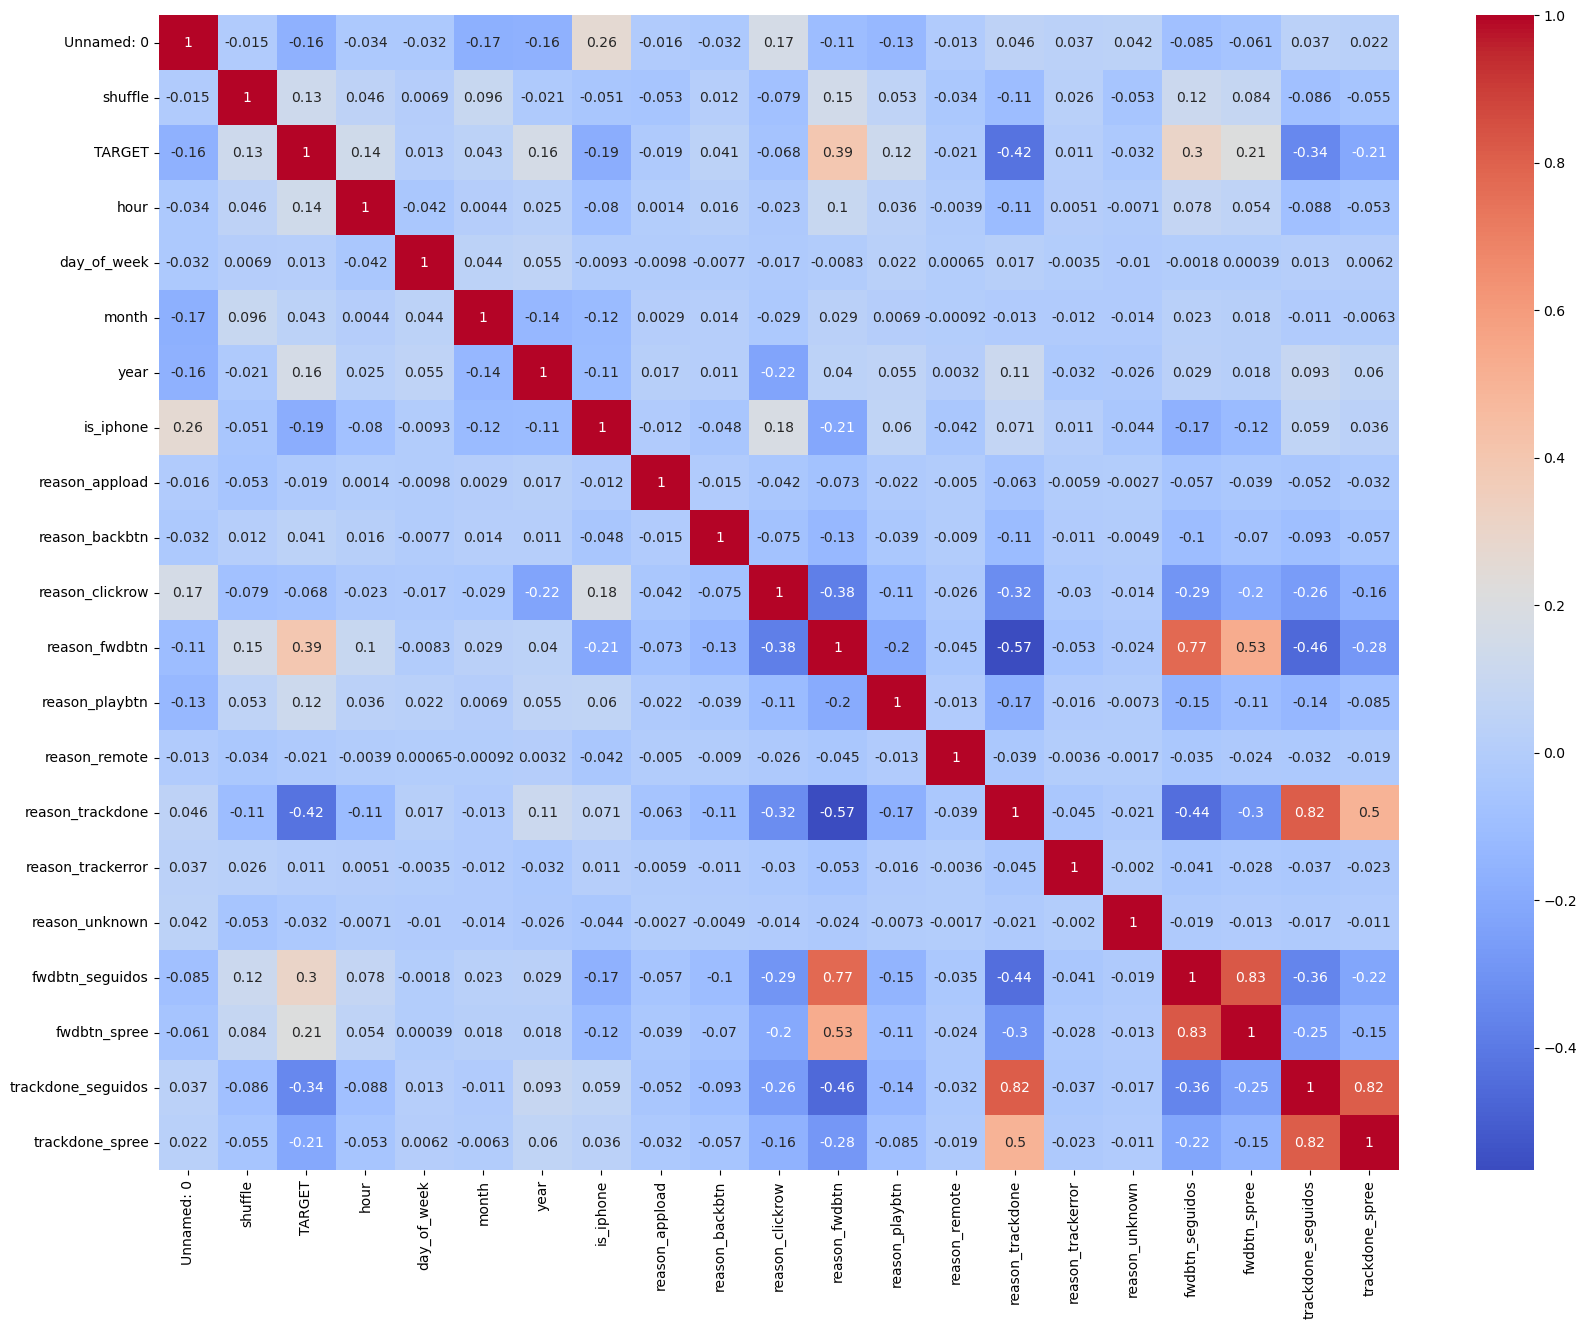

In [153]:
plt.figure(figsize=(20, 15)) 
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

Relación entre razón de reproducción y la variable a predecir

<Figure size 1200x600 with 0 Axes>

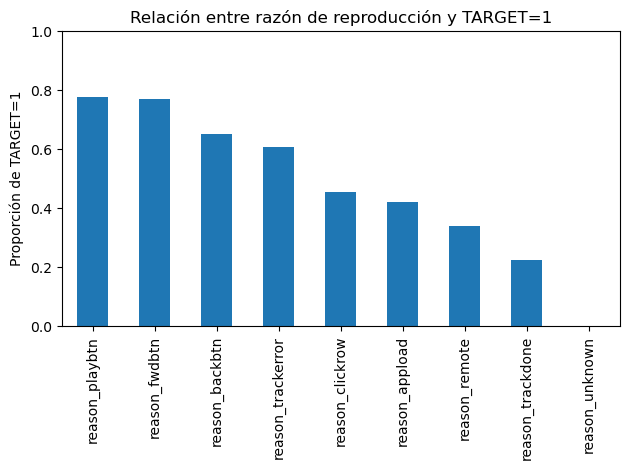

In [154]:
one_hot_cols = [col for col in data.columns if col.startswith('reason_')] 

category_target_means = {
    col: data.loc[data[col] == 1, 'TARGET'].mean()
    for col in one_hot_cols
}

mean_df = pd.DataFrame.from_dict(category_target_means, orient='index', columns=['TARGET_mean'])
mean_df = mean_df.sort_values(by='TARGET_mean', ascending=False)

plt.figure(figsize=(12,6))
mean_df.plot(kind='bar', legend=False)
plt.title('Relación entre razón de reproducción y TARGET=1')
plt.ylabel('Proporción de TARGET=1')
plt.xticks(rotation=90)
plt.tight_layout()
plt.ylim(0, 1)
plt.show()

<Figure size 1200x600 with 0 Axes>

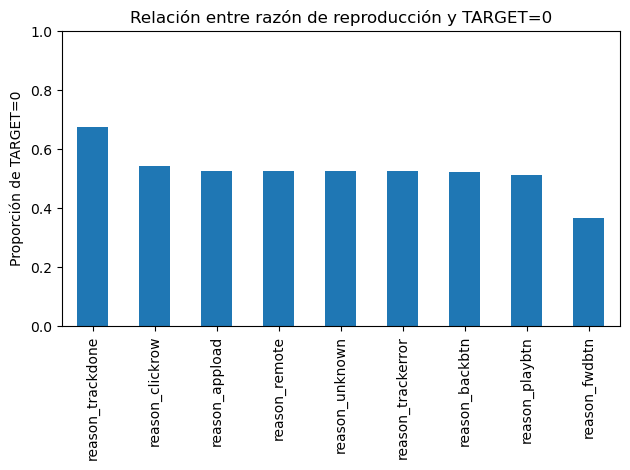

In [155]:
one_hot_cols = [col for col in data.columns if col.startswith('reason_')] 

category_target_means = {
    col: data.loc[data[col] == 0, 'TARGET'].mean()
    for col in one_hot_cols
}

mean_df = pd.DataFrame.from_dict(category_target_means, orient='index', columns=['TARGET_mean'])
mean_df = mean_df.sort_values(by='TARGET_mean', ascending=False)

plt.figure(figsize=(12,6))
mean_df.plot(kind='bar', legend=False)
plt.title('Relación entre razón de reproducción y TARGET=0')
plt.ylabel('Proporción de TARGET=0')
plt.xticks(rotation=90)
plt.tight_layout()
plt.ylim(0, 1)
plt.show()